# Semantic Search Evaluation

Evaluation using:
- **Embedding Model:** `cohere/embed-english-v3.0`
- **Reranker:** `cohere/rerank-english-v3.0`

**Metrics:**
- Recall@k (k=10, 50, 100)
- Precision@k (k=10, 50, 100)
- nDCG@10
- MRR (Mean Reciprocal Rank)
- InfoNCE Loss (τ=0.07)


In [1]:
import json
import requests
import numpy as np
from typing import Any, Dict, List, Set
from tqdm import tqdm
import time

# Load data
with open("/home/ola/semantic-search-langsmith/setup_db/queries_subset.json", "r", encoding="utf-8") as f:
    queries = json.load(f)

with open("/home/ola/semantic-search-langsmith/setup_db/qrels_subset.json", "r", encoding="utf-8") as f:
    qrels = json.load(f)

print(f"Loaded {len(queries)} queries and {len(qrels)} qrels")


Loaded 49 queries and 49 qrels


In [1]:
!pip install python-dotenv


Defaulting to user installation because normal site-packages is not writeable


In [ ]:
from dotenv import load_dotenv
import os

load_dotenv()  # looks for a .env file in the current directory

langsmith_api_key = os.getenv("LANGSMITH_API_KEY")

In [ ]:
# API Configuration
assistant_id = "393b8167-6b9c-4b1c-8dba-e2e5b79dbc4b"
deployment_url = "https://semantic-search-agent-c9c1c583c97f571e95749e599666ba0e.us.langgraph.app"

# Model configuration
EMBEDDING_MODEL = "cohere/embed-english-v3.0"
RERANKER_MODEL = "cohere/rerank-english-v3.0"
MAX_K = 100  # Maximum k for evaluation

def run_query(query_text: str, k: int = 100) -> Dict[str, Any]:
    """Run a single query through the semantic search API."""
    response = requests.post(
        f"{deployment_url}/runs/wait",
        headers={
            "Content-Type": "application/json",
            "X-Api-Key": langsmith_api_key
        },
        json={
            "assistant_id": assistant_id,
            "input": {
                "messages": [
                    {"role": "human", "content": query_text}
                ]
            },
            "config": {
                "configurable": {
                    "embedding_model": EMBEDDING_MODEL,
                    "reranker_model": RERANKER_MODEL,
                    "search_kwargs": {"k": k}
                }
            }
        },
        timeout=120
    )
    return response.json()

def extract_doc_ids(payload: Dict[str, Any], k: int = 100) -> List[str]:
    """Extract document IDs from API response, preserving ranking order."""
    docs = payload.get("reranked_docs") or payload.get("retrieved_docs") or []
    doc_ids = []
    for d in docs[:k]:
        md = d.get("metadata") or {}
        doc_id = md.get("doc_id") or md.get("_id") or d.get("id")
        if doc_id is not None:
            doc_ids.append(str(doc_id))
    return doc_ids

print(f"Configuration:")
print(f"  Embedding Model: {EMBEDDING_MODEL}")
print(f"  Reranker Model: {RERANKER_MODEL}")
print(f"  Max K: {MAX_K}")


Configuration:
  Embedding Model: cohere/embed-english-v3.0
  Reranker Model: cohere/rerank-english-v3.0
  Max K: 100


In [3]:
# ============================================================================
# METRIC FUNCTIONS
# ============================================================================

def recall_at_k(retrieved_ids: List[str], relevant_ids: Set[str], k: int) -> float:
    """
    Recall@k: fraction of relevant docs retrieved in top-k.
    Recall@k = |relevant ∩ retrieved@k| / |relevant|
    """
    if not relevant_ids:
        return 0.0
    retrieved_at_k = set(retrieved_ids[:k])
    return len(relevant_ids & retrieved_at_k) / len(relevant_ids)


def precision_at_k(retrieved_ids: List[str], relevant_ids: Set[str], k: int) -> float:
    """
    Precision@k: fraction of top-k that are relevant.
    Precision@k = |relevant ∩ retrieved@k| / k
    """
    if k == 0:
        return 0.0
    retrieved_at_k = set(retrieved_ids[:k])
    return len(relevant_ids & retrieved_at_k) / k


def dcg_at_k(retrieved_ids: List[str], relevant_ids: Set[str], k: int) -> float:
    """
    Discounted Cumulative Gain at k.
    DCG@k = Σ (rel_i / log2(i+1)) for i in 1..k
    """
    dcg = 0.0
    for i, doc_id in enumerate(retrieved_ids[:k]):
        rel = 1.0 if doc_id in relevant_ids else 0.0
        dcg += rel / np.log2(i + 2)  # i+2 because i is 0-indexed
    return dcg


def ndcg_at_k(retrieved_ids: List[str], relevant_ids: Set[str], k: int) -> float:
    """
    Normalized Discounted Cumulative Gain at k.
    nDCG@k = DCG@k / IDCG@k
    """
    dcg = dcg_at_k(retrieved_ids, relevant_ids, k)
    
    # IDCG: ideal DCG (all relevant docs at the top)
    num_relevant = min(len(relevant_ids), k)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(num_relevant))
    
    if idcg == 0:
        return 0.0
    return dcg / idcg


def mrr(retrieved_ids: List[str], relevant_ids: Set[str]) -> float:
    """
    Mean Reciprocal Rank: 1 / rank of first relevant document.
    """
    for i, doc_id in enumerate(retrieved_ids):
        if doc_id in relevant_ids:
            return 1.0 / (i + 1)
    return 0.0


def infonce_loss(retrieved_ids: List[str], relevant_ids: Set[str], 
                 scores: List[float] = None, tau: float = 0.07) -> float:
    """
    InfoNCE Contrastive Loss with temperature τ.
    
    L = -log(exp(s_pos/τ) / Σ exp(s_i/τ))
    
    If scores not provided, uses rank-based proxy scores:
    score = 1 / (rank + 1)
    """
    if not retrieved_ids or not relevant_ids:
        return float('inf')
    
    # Generate proxy scores based on rank if not provided
    if scores is None:
        scores = [1.0 / (i + 1) for i in range(len(retrieved_ids))]
    
    # Find the positive (relevant) document scores
    pos_scores = []
    all_scores = []
    
    for i, doc_id in enumerate(retrieved_ids):
        score = scores[i] if i < len(scores) else 0.0
        all_scores.append(score)
        if doc_id in relevant_ids:
            pos_scores.append(score)
    
    if not pos_scores:
        return float('inf')  # No relevant docs retrieved
    
    # Compute InfoNCE loss for the highest-scoring positive
    pos_score = max(pos_scores)
    
    # Numerical stability: subtract max before exp
    max_score = max(all_scores)
    exp_pos = np.exp((pos_score - max_score) / tau)
    exp_sum = sum(np.exp((s - max_score) / tau) for s in all_scores)
    
    loss = -np.log(exp_pos / exp_sum + 1e-10)
    return loss


print("Metric functions defined:")
print("  - recall_at_k(retrieved_ids, relevant_ids, k)")
print("  - precision_at_k(retrieved_ids, relevant_ids, k)")
print("  - ndcg_at_k(retrieved_ids, relevant_ids, k)")
print("  - mrr(retrieved_ids, relevant_ids)")
print("  - infonce_loss(retrieved_ids, relevant_ids, scores, tau=0.07)")


Metric functions defined:
  - recall_at_k(retrieved_ids, relevant_ids, k)
  - precision_at_k(retrieved_ids, relevant_ids, k)
  - ndcg_at_k(retrieved_ids, relevant_ids, k)
  - mrr(retrieved_ids, relevant_ids)
  - infonce_loss(retrieved_ids, relevant_ids, scores, tau=0.07)


In [4]:
# ============================================================================
# RUN EVALUATION
# ============================================================================

# Store results for each query
results = {}
errors = []

print(f"Running evaluation on {len(queries)} queries...")
print(f"This may take a few minutes due to API rate limits.\n")

for query_id, query_text in tqdm(queries.items(), desc="Evaluating queries"):
    try:
        # Run query through API
        response = run_query(query_text, k=MAX_K)
        
        # Extract document IDs
        retrieved_ids = extract_doc_ids(response, k=MAX_K)
        
        # Get relevance scores from response (if available)
        docs = response.get("reranked_docs") or response.get("retrieved_docs") or []
        scores = []
        for d in docs[:MAX_K]:
            md = d.get("metadata") or {}
            score = md.get("relevance_score") or md.get("score") or 0.0
            scores.append(float(score) if score else 0.0)
        
        # Get relevant doc IDs from qrels
        relevant_docs = qrels.get(query_id, {})
        relevant_ids = set(str(doc_id) for doc_id in relevant_docs.keys())
        
        # Store results
        results[query_id] = {
            "query_text": query_text,
            "retrieved_ids": retrieved_ids,
            "relevant_ids": relevant_ids,
            "scores": scores,
            "num_retrieved": len(retrieved_ids),
            "num_relevant": len(relevant_ids)
        }
        
        # Small delay to avoid rate limiting
        time.sleep(0.5)
        
    except Exception as e:
        errors.append((query_id, str(e)))
        print(f"\nError on query {query_id}: {e}")

print(f"\n✓ Completed {len(results)} queries")
if errors:
    print(f"✗ {len(errors)} errors: {errors}")


Running evaluation on 49 queries...
This may take a few minutes due to API rate limits.



Evaluating queries: 100%|██████████| 49/49 [02:04<00:00,  2.55s/it]


✓ Completed 49 queries


In [5]:
# ============================================================================
# COMPUTE METRICS
# ============================================================================

K_VALUES = [10, 50, 100]
TAU = 0.07

# Per-query metrics
query_metrics = []

for query_id, data in results.items():
    retrieved_ids = data["retrieved_ids"]
    relevant_ids = data["relevant_ids"]
    scores = data["scores"]
    
    metrics = {
        "query_id": query_id,
        "query_text": data["query_text"][:50] + "..." if len(data["query_text"]) > 50 else data["query_text"],
        "num_retrieved": data["num_retrieved"],
        "num_relevant": data["num_relevant"],
    }
    
    # Recall@k
    for k in K_VALUES:
        metrics[f"recall@{k}"] = recall_at_k(retrieved_ids, relevant_ids, k)
    
    # Precision@k
    for k in K_VALUES:
        metrics[f"precision@{k}"] = precision_at_k(retrieved_ids, relevant_ids, k)
    
    # nDCG@10
    metrics["ndcg@10"] = ndcg_at_k(retrieved_ids, relevant_ids, 10)
    
    # MRR
    metrics["mrr"] = mrr(retrieved_ids, relevant_ids)
    
    # InfoNCE Loss
    metrics["infonce_loss"] = infonce_loss(retrieved_ids, relevant_ids, scores, tau=TAU)
    
    query_metrics.append(metrics)

print(f"Computed metrics for {len(query_metrics)} queries")


Computed metrics for 49 queries


In [6]:
# ============================================================================
# AGGREGATE RESULTS
# ============================================================================

import pandas as pd

# Create DataFrame for per-query results
df_queries = pd.DataFrame(query_metrics)

# Compute aggregate metrics (mean across all queries)
metric_columns = [col for col in df_queries.columns if col not in ["query_id", "query_text", "num_retrieved", "num_relevant"]]

# Filter out infinite values for InfoNCE loss when computing mean
def safe_mean(series):
    finite_vals = series[np.isfinite(series)]
    return finite_vals.mean() if len(finite_vals) > 0 else float('inf')

aggregate_metrics = {}
for col in metric_columns:
    if col == "infonce_loss":
        aggregate_metrics[col] = safe_mean(df_queries[col])
    else:
        aggregate_metrics[col] = df_queries[col].mean()

print("=" * 70)
print("EVALUATION RESULTS")
print("=" * 70)
print(f"\nModels:")
print(f"  Embedding: {EMBEDDING_MODEL}")
print(f"  Reranker:  {RERANKER_MODEL}")
print(f"\nDataset: {len(queries)} queries")
print("=" * 70)

print("\n📊 AGGREGATE METRICS (Mean across all queries)")
print("-" * 50)

# Recall
print("\n🔍 Recall@k (fraction of relevant docs retrieved):")
for k in K_VALUES:
    print(f"   Recall@{k:3d}: {aggregate_metrics[f'recall@{k}']:.4f}")

# Precision
print("\n🎯 Precision@k (fraction of top-k that are relevant):")
for k in K_VALUES:
    print(f"   Precision@{k:3d}: {aggregate_metrics[f'precision@{k}']:.4f}")

# nDCG
print("\n📈 Ranking Quality:")
print(f"   nDCG@10: {aggregate_metrics['ndcg@10']:.4f}")

# MRR
print(f"\n🥇 Mean Reciprocal Rank:")
print(f"   MRR: {aggregate_metrics['mrr']:.4f}")

# InfoNCE
print(f"\n📉 InfoNCE Loss (τ={TAU}):")
infonce_val = aggregate_metrics['infonce_loss']
if np.isfinite(infonce_val):
    print(f"   InfoNCE: {infonce_val:.4f}")
else:
    print(f"   InfoNCE: ∞ (no relevant docs found for some queries)")

print("\n" + "=" * 70)


EVALUATION RESULTS

Models:
  Embedding: cohere/embed-english-v3.0
  Reranker:  cohere/rerank-english-v3.0

Dataset: 49 queries

📊 AGGREGATE METRICS (Mean across all queries)
--------------------------------------------------

🔍 Recall@k (fraction of relevant docs retrieved):
   Recall@ 10: 0.8605
   Recall@ 50: 0.9388
   Recall@100: 0.9388

🎯 Precision@k (fraction of top-k that are relevant):
   Precision@ 10: 0.0939
   Precision@ 50: 0.0208
   Precision@100: 0.0104

📈 Ranking Quality:
   nDCG@10: 0.7095

🥇 Mean Reciprocal Rank:
   MRR: 0.6730

📉 InfoNCE Loss (τ=0.07):
   InfoNCE: 2.9741



In [7]:
# ============================================================================
# PER-QUERY RESULTS TABLE
# ============================================================================

# Display per-query results
display_cols = ["query_id", "recall@10", "precision@10", "ndcg@10", "mrr", "infonce_loss"]
df_display = df_queries[display_cols].copy()

# Format numeric columns
for col in display_cols[1:]:
    df_display[col] = df_display[col].apply(lambda x: f"{x:.4f}" if np.isfinite(x) else "∞")

print("\n📋 PER-QUERY METRICS:")
df_display



📋 PER-QUERY METRICS:


,query_id,recall@10,precision@10,ndcg@10,mrr,infonce_loss
0,18,1.0000,0.1000,0.2891,0.1000,4.5926
1,68,0.0000,0.0000,0.0000,0.0238,4.6243
2,90,1.0000,0.1000,1.0000,1.0000,0.0861
3,106,1.0000,0.1000,1.0000,1.0000,2.8742
4,109,1.0000,0.1000,1.0000,1.0000,0.0001
5,810,1.0000,0.1000,0.5000,0.3333,2.5338
6,1198,1.0000,0.1000,1.0000,1.0000,0.7412
7,2513,1.0000,0.1000,0.4307,0.2500,4.5755
8,2549,0.5000,0.1000,0.6131,1.0000,3.5735
9,2587,1.0000,0.1000,1.0000,1.0000,0.0001


In [8]:
# ============================================================================
# SUMMARY TABLE
# ============================================================================

# Create a clean summary dataframe
summary_data = {
    "Metric": [],
    "Value": []
}

# Add all metrics
for k in K_VALUES:
    summary_data["Metric"].append(f"Recall@{k}")
    summary_data["Value"].append(f"{aggregate_metrics[f'recall@{k}']:.4f}")

for k in K_VALUES:
    summary_data["Metric"].append(f"Precision@{k}")
    summary_data["Value"].append(f"{aggregate_metrics[f'precision@{k}']:.4f}")

summary_data["Metric"].append("nDCG@10")
summary_data["Value"].append(f"{aggregate_metrics['ndcg@10']:.4f}")

summary_data["Metric"].append("MRR")
summary_data["Value"].append(f"{aggregate_metrics['mrr']:.4f}")

infonce_val = aggregate_metrics['infonce_loss']
summary_data["Metric"].append(f"InfoNCE (τ={TAU})")
summary_data["Value"].append(f"{infonce_val:.4f}" if np.isfinite(infonce_val) else "∞")

df_summary = pd.DataFrame(summary_data)
print("\n📊 SUMMARY TABLE:")
df_summary



📊 SUMMARY TABLE:


,Metric,Value
0,Recall@10,0.8605
1,Recall@50,0.9388
2,Recall@100,0.9388
3,Precision@10,0.0939
4,Precision@50,0.0208
5,Precision@100,0.0104
6,nDCG@10,0.7095
7,MRR,0.6730
8,InfoNCE (τ=0.07),2.9741


In [9]:
# ============================================================================
# EXPORT RESULTS
# ============================================================================

# Convert sets to lists for JSON serialization
export_results = {
    "config": {
        "embedding_model": EMBEDDING_MODEL,
        "reranker_model": RERANKER_MODEL,
        "k_values": K_VALUES,
        "tau": TAU,
        "num_queries": len(queries)
    },
    "aggregate_metrics": {k: (v if np.isfinite(v) else None) for k, v in aggregate_metrics.items()},
    "per_query_metrics": query_metrics
}

# Save to JSON
output_path = "/home/ola/semantic-search-langsmith/evaluation_results.json"
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(export_results, f, indent=2, default=str)

print(f"✓ Results exported to: {output_path}")


✓ Results exported to: /home/ola/semantic-search-langsmith/evaluation_results.json


# Adversarial Robustness Evaluation

Test robustness by paraphrasing queries using GPT-4o via OpenRouter, then re-evaluating retrieval performance.


In [10]:
# ============================================================================
# ADVERSARIAL PARAPHRASING SETUP
# ============================================================================

import os

# OpenRouter API configuration
OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY", "YOUR_OPENROUTER_API_KEY")  # Set your key here or via env
OPENROUTER_URL = "https://openrouter.ai/api/v1/chat/completions"

PARAPHRASE_PROMPT = """You are a query paraphrasing assistant. Rewrite the following search query using different words and phrasing while preserving the exact same meaning and intent. 

Rules:
- Keep the same information need
- Use synonyms and alternative phrasings
- Maintain the question format if it's a question
- Do NOT add or remove information
- Output ONLY the paraphrased query, nothing else

Original query: {query}

Paraphrased query:"""


def paraphrase_query(query: str, model: str = "openai/gpt-4o") -> str:
    """Paraphrase a query using GPT-4o via OpenRouter."""
    try:
        response = requests.post(
            OPENROUTER_URL,
            headers={
                "Authorization": f"Bearer {OPENROUTER_API_KEY}",
                "Content-Type": "application/json",
                "HTTP-Referer": "https://semantic-search-eval.local",
            },
            json={
                "model": model,
                "messages": [
                    {"role": "user", "content": PARAPHRASE_PROMPT.format(query=query)}
                ],
                "temperature": 0.7,
                "max_tokens": 256,
            },
            timeout=60
        )
        result = response.json()
        paraphrased = result["choices"][0]["message"]["content"].strip()
        # Clean up any quotes that might wrap the response
        paraphrased = paraphrased.strip('"\'')
        return paraphrased
    except Exception as e:
        print(f"Paraphrase error: {e}")
        return query  # Return original if paraphrasing fails


print("Paraphrase function ready")
print(f"Using OpenRouter model: openai/gpt-4o")


Paraphrase function ready
Using OpenRouter model: openai/gpt-4o


In [11]:
# ============================================================================
# GENERATE PARAPHRASED QUERIES
# ============================================================================

NUM_PARAPHRASES = 1  # k=1 paraphrase per query

paraphrased_queries = {}
paraphrase_errors = []

print(f"Generating {NUM_PARAPHRASES} paraphrase(s) per query for {len(queries)} queries...")
print("This may take a few minutes...\n")

for query_id, original_query in tqdm(queries.items(), desc="Paraphrasing"):
    try:
        paraphrased = paraphrase_query(original_query)
        paraphrased_queries[query_id] = {
            "original": original_query,
            "paraphrased": paraphrased
        }
        time.sleep(0.3)  # Rate limiting
    except Exception as e:
        paraphrase_errors.append((query_id, str(e)))
        paraphrased_queries[query_id] = {
            "original": original_query,
            "paraphrased": original_query  # Fallback to original
        }

print(f"\n✓ Generated paraphrases for {len(paraphrased_queries)} queries")
if paraphrase_errors:
    print(f"✗ {len(paraphrase_errors)} errors")

# Show some examples
print("\n📝 Example paraphrases:")
for i, (qid, data) in enumerate(list(paraphrased_queries.items())[:3]):
    print(f"\n  Query {qid}:")
    print(f"    Original:    {data['original'][:70]}...")
    print(f"    Paraphrased: {data['paraphrased'][:70]}...")


Generating 1 paraphrase(s) per query for 49 queries...
This may take a few minutes...



Paraphrasing: 100%|██████████| 49/49 [01:06<00:00,  1.35s/it]


✓ Generated paraphrases for 49 queries

📝 Example paraphrases:

  Query 18:
    Original:    1 EIN doing business under multiple business names...
    Paraphrased: Can a single EIN be used for various business names?...

  Query 68:
    Original:    Intentions of Deductible Amount for Small Business...
    Paraphrased: Purpose of Deductible Sum for Small Enterprises...

  Query 90:
    Original:    Filing personal with 1099s versus business s-corp?...
    Paraphrased: Comparing personal filing with 1099 forms to business S-corp filing?...


In [12]:
# ============================================================================
# RUN EVALUATION ON PARAPHRASED QUERIES
# ============================================================================

robust_results = {}
robust_errors = []

print(f"Running evaluation on {len(paraphrased_queries)} paraphrased queries...")
print(f"This may take a few minutes due to API rate limits.\n")

for query_id, query_data in tqdm(paraphrased_queries.items(), desc="Evaluating paraphrased"):
    try:
        paraphrased_text = query_data["paraphrased"]
        
        # Run paraphrased query through API
        response = run_query(paraphrased_text, k=MAX_K)
        
        # Extract document IDs
        retrieved_ids = extract_doc_ids(response, k=MAX_K)
        
        # Get relevance scores from response
        docs = response.get("reranked_docs") or response.get("retrieved_docs") or []
        scores = []
        for d in docs[:MAX_K]:
            md = d.get("metadata") or {}
            score = md.get("relevance_score") or md.get("score") or 0.0
            scores.append(float(score) if score else 0.0)
        
        # Get relevant doc IDs from qrels (same ground truth)
        relevant_docs = qrels.get(query_id, {})
        relevant_ids = set(str(doc_id) for doc_id in relevant_docs.keys())
        
        # Store results
        robust_results[query_id] = {
            "original_query": query_data["original"],
            "paraphrased_query": paraphrased_text,
            "retrieved_ids": retrieved_ids,
            "relevant_ids": relevant_ids,
            "scores": scores,
            "num_retrieved": len(retrieved_ids),
            "num_relevant": len(relevant_ids)
        }
        
        time.sleep(0.5)
        
    except Exception as e:
        robust_errors.append((query_id, str(e)))
        print(f"\nError on query {query_id}: {e}")

print(f"\n✓ Completed {len(robust_results)} paraphrased queries")
if robust_errors:
    print(f"✗ {len(robust_errors)} errors: {robust_errors}")


Running evaluation on 49 paraphrased queries...
This may take a few minutes due to API rate limits.



Evaluating paraphrased: 100%|██████████| 49/49 [02:00<00:00,  2.46s/it]


✓ Completed 49 paraphrased queries


In [13]:
# ============================================================================
# COMPUTE ROBUST METRICS
# ============================================================================

# Per-query robust metrics
robust_query_metrics = []

for query_id, data in robust_results.items():
    retrieved_ids = data["retrieved_ids"]
    relevant_ids = data["relevant_ids"]
    scores = data["scores"]
    
    metrics = {
        "query_id": query_id,
        "original_query": data["original_query"][:40] + "..." if len(data["original_query"]) > 40 else data["original_query"],
        "paraphrased_query": data["paraphrased_query"][:40] + "..." if len(data["paraphrased_query"]) > 40 else data["paraphrased_query"],
        "num_retrieved": data["num_retrieved"],
        "num_relevant": data["num_relevant"],
    }
    
    # Recall@k
    for k in K_VALUES:
        metrics[f"recall@{k}"] = recall_at_k(retrieved_ids, relevant_ids, k)
    
    # Precision@k
    for k in K_VALUES:
        metrics[f"precision@{k}"] = precision_at_k(retrieved_ids, relevant_ids, k)
    
    # nDCG@10
    metrics["ndcg@10"] = ndcg_at_k(retrieved_ids, relevant_ids, 10)
    
    # MRR
    metrics["mrr"] = mrr(retrieved_ids, relevant_ids)
    
    # InfoNCE Loss
    metrics["infonce_loss"] = infonce_loss(retrieved_ids, relevant_ids, scores, tau=TAU)
    
    robust_query_metrics.append(metrics)

# Create DataFrame
df_robust = pd.DataFrame(robust_query_metrics)

# Compute aggregate robust metrics
robust_aggregate_metrics = {}
for col in metric_columns:
    if col == "infonce_loss":
        robust_aggregate_metrics[col] = safe_mean(df_robust[col])
    else:
        robust_aggregate_metrics[col] = df_robust[col].mean()

print(f"Computed robust metrics for {len(robust_query_metrics)} paraphrased queries")


Computed robust metrics for 49 paraphrased queries


In [14]:
# ============================================================================
# CLEAN vs ROBUST COMPARISON TABLE
# ============================================================================

comparison_data = {
    "Metric": [],
    "Clean Value": [],
    "Robust Value": [],
    "Δ (Robust - Clean)": [],
    "% Change": []
}

# Define metrics to compare
metrics_to_compare = [
    ("Recall@10", "recall@10"),
    ("Recall@50", "recall@50"),
    ("Recall@100", "recall@100"),
    ("Precision@10", "precision@10"),
    ("Precision@50", "precision@50"),
    ("Precision@100", "precision@100"),
    ("nDCG@10", "ndcg@10"),
    ("MRR", "mrr"),
    (f"InfoNCE (τ={TAU})", "infonce_loss"),
]

for display_name, metric_key in metrics_to_compare:
    clean_val = aggregate_metrics[metric_key]
    robust_val = robust_aggregate_metrics[metric_key]
    
    comparison_data["Metric"].append(display_name)
    
    if np.isfinite(clean_val):
        comparison_data["Clean Value"].append(f"{clean_val:.4f}")
    else:
        comparison_data["Clean Value"].append("∞")
    
    if np.isfinite(robust_val):
        comparison_data["Robust Value"].append(f"{robust_val:.4f}")
    else:
        comparison_data["Robust Value"].append("∞")
    
    # Compute delta and percentage change
    if np.isfinite(clean_val) and np.isfinite(robust_val):
        delta = robust_val - clean_val
        comparison_data["Δ (Robust - Clean)"].append(f"{delta:+.4f}")
        
        if clean_val != 0:
            pct_change = (delta / abs(clean_val)) * 100
            comparison_data["% Change"].append(f"{pct_change:+.1f}%")
        else:
            comparison_data["% Change"].append("N/A")
    else:
        comparison_data["Δ (Robust - Clean)"].append("N/A")
        comparison_data["% Change"].append("N/A")

df_comparison = pd.DataFrame(comparison_data)

print("=" * 80)
print("CLEAN vs ROBUST COMPARISON")
print("=" * 80)
print(f"\nEmbedding: {EMBEDDING_MODEL}")
print(f"Reranker:  {RERANKER_MODEL}")
print(f"Paraphrase Model: GPT-4o via OpenRouter")
print(f"Queries: {len(queries)}")
print("=" * 80)
print()
df_comparison


CLEAN vs ROBUST COMPARISON

Embedding: cohere/embed-english-v3.0
Reranker:  cohere/rerank-english-v3.0
Paraphrase Model: GPT-4o via OpenRouter
Queries: 49



,Metric,Clean Value,Robust Value,Δ (Robust - Clean),% Change
0,Recall@10,0.8605,0.8673,+0.0068,+0.8%
1,Recall@50,0.9388,0.9592,+0.0204,+2.2%
2,Recall@100,0.9388,0.9592,+0.0204,+2.2%
3,Precision@10,0.0939,0.0959,+0.0020,+2.2%
4,Precision@50,0.0208,0.0212,+0.0004,+2.0%
5,Precision@100,0.0104,0.0106,+0.0002,+2.0%
6,nDCG@10,0.7095,0.7096,+0.0001,+0.0%
7,MRR,0.6730,0.6686,-0.0045,-0.7%
8,InfoNCE (τ=0.07),2.9741,3.5291,+0.5550,+18.7%


/tmp/ipykernel_1875686/1339742223.py:93: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax3.boxplot(box_data, labels=['Clean', 'Robust'], patch_artist=True, widths=0.6)


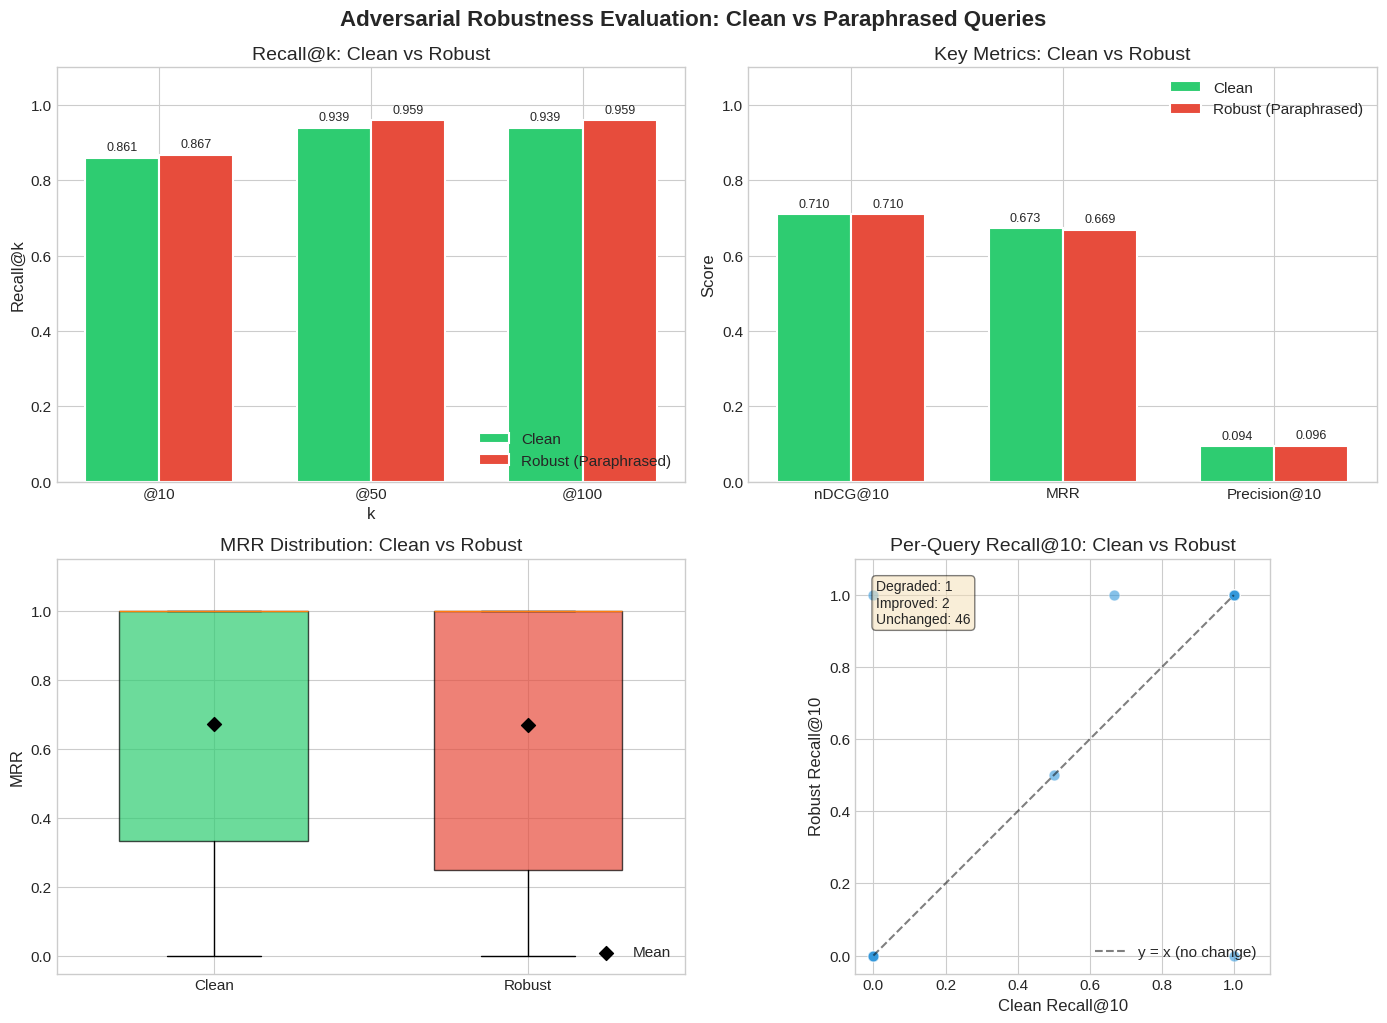


✓ Visualization saved to: robustness_evaluation.png


In [15]:
# ============================================================================
# VISUALIZATIONS
# ============================================================================

import matplotlib.pyplot as plt

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Color palette
CLEAN_COLOR = '#2ecc71'  # Green
ROBUST_COLOR = '#e74c3c'  # Red
NEUTRAL_COLOR = '#3498db'  # Blue

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ============================================================================
# Plot 1: Recall@k Comparison (Bar Chart)
# ============================================================================
ax1 = axes[0, 0]
k_values = [10, 50, 100]
x = np.arange(len(k_values))
width = 0.35

clean_recalls = [aggregate_metrics[f'recall@{k}'] for k in k_values]
robust_recalls = [robust_aggregate_metrics[f'recall@{k}'] for k in k_values]

bars1 = ax1.bar(x - width/2, clean_recalls, width, label='Clean', color=CLEAN_COLOR, edgecolor='white', linewidth=1.5)
bars2 = ax1.bar(x + width/2, robust_recalls, width, label='Robust (Paraphrased)', color=ROBUST_COLOR, edgecolor='white', linewidth=1.5)

ax1.set_xlabel('k')
ax1.set_ylabel('Recall@k')
ax1.set_title('Recall@k: Clean vs Robust')
ax1.set_xticks(x)
ax1.set_xticklabels([f'@{k}' for k in k_values])
ax1.legend(loc='lower right')
ax1.set_ylim(0, 1.1)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax1.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    ax1.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

# ============================================================================
# Plot 2: Key Metrics Comparison (Grouped Bar)
# ============================================================================
ax2 = axes[0, 1]
key_metrics = ['nDCG@10', 'MRR', 'Precision@10']
metric_keys = ['ndcg@10', 'mrr', 'precision@10']
x = np.arange(len(key_metrics))

clean_vals = [aggregate_metrics[k] for k in metric_keys]
robust_vals = [robust_aggregate_metrics[k] for k in metric_keys]

bars1 = ax2.bar(x - width/2, clean_vals, width, label='Clean', color=CLEAN_COLOR, edgecolor='white', linewidth=1.5)
bars2 = ax2.bar(x + width/2, robust_vals, width, label='Robust (Paraphrased)', color=ROBUST_COLOR, edgecolor='white', linewidth=1.5)

ax2.set_ylabel('Score')
ax2.set_title('Key Metrics: Clean vs Robust')
ax2.set_xticks(x)
ax2.set_xticklabels(key_metrics)
ax2.legend(loc='upper right')
ax2.set_ylim(0, 1.1)

for bar in bars1:
    height = bar.get_height()
    ax2.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    ax2.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

# ============================================================================
# Plot 3: Per-Query MRR Distribution (Box Plot)
# ============================================================================
ax3 = axes[1, 0]

# Merge clean and robust MRR values
clean_mrr_values = df_queries['mrr'].values
robust_mrr_values = df_robust['mrr'].values

box_data = [clean_mrr_values, robust_mrr_values]
bp = ax3.boxplot(box_data, labels=['Clean', 'Robust'], patch_artist=True, widths=0.6)

# Color the boxes
bp['boxes'][0].set_facecolor(CLEAN_COLOR)
bp['boxes'][1].set_facecolor(ROBUST_COLOR)
for box in bp['boxes']:
    box.set_alpha(0.7)

ax3.set_ylabel('MRR')
ax3.set_title('MRR Distribution: Clean vs Robust')
ax3.set_ylim(-0.05, 1.15)

# Add mean markers
means = [np.mean(clean_mrr_values), np.mean(robust_mrr_values)]
ax3.scatter([1, 2], means, marker='D', color='black', s=50, zorder=5, label=f'Mean')
ax3.legend(loc='lower right')

# ============================================================================
# Plot 4: Per-Query Recall@10 Scatter (Clean vs Robust)
# ============================================================================
ax4 = axes[1, 1]

# Match queries by ID
query_ids = list(results.keys())
clean_recall10 = [results[qid]['retrieved_ids'] for qid in query_ids]
robust_recall10 = [robust_results[qid]['retrieved_ids'] for qid in query_ids if qid in robust_results]

# Compute recall@10 for each query
clean_r10 = []
robust_r10 = []
for qid in query_ids:
    if qid in robust_results:
        rel_ids = results[qid]['relevant_ids']
        clean_r10.append(recall_at_k(results[qid]['retrieved_ids'], rel_ids, 10))
        robust_r10.append(recall_at_k(robust_results[qid]['retrieved_ids'], rel_ids, 10))

ax4.scatter(clean_r10, robust_r10, alpha=0.6, s=60, c=NEUTRAL_COLOR, edgecolors='white', linewidth=0.5)
ax4.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='y = x (no change)')
ax4.set_xlabel('Clean Recall@10')
ax4.set_ylabel('Robust Recall@10')
ax4.set_title('Per-Query Recall@10: Clean vs Robust')
ax4.set_xlim(-0.05, 1.1)
ax4.set_ylim(-0.05, 1.1)
ax4.legend(loc='lower right')
ax4.set_aspect('equal')

# Add annotation for degraded queries
degraded = sum(1 for c, r in zip(clean_r10, robust_r10) if r < c)
improved = sum(1 for c, r in zip(clean_r10, robust_r10) if r > c)
unchanged = sum(1 for c, r in zip(clean_r10, robust_r10) if r == c)
ax4.annotate(f'Degraded: {degraded}\nImproved: {improved}\nUnchanged: {unchanged}', 
             xy=(0.05, 0.95), xycoords='axes fraction', va='top', fontsize=10,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.suptitle('Adversarial Robustness Evaluation: Clean vs Paraphrased Queries', 
             fontsize=16, fontweight='bold', y=1.02)
plt.savefig('/home/ola/semantic-search-langsmith/robustness_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Visualization saved to: robustness_evaluation.png")


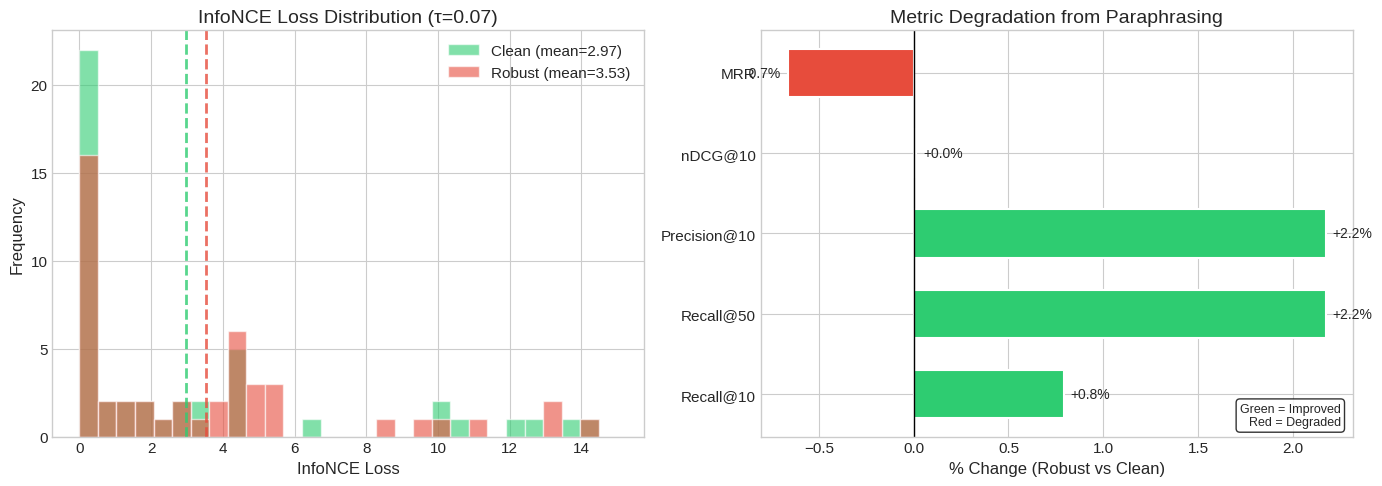


✓ Additional visualization saved to: robustness_details.png


In [16]:
# ============================================================================
# ADDITIONAL VISUALIZATION: InfoNCE Loss & Metric Degradation Heatmap
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ============================================================================
# Plot 1: InfoNCE Loss Distribution
# ============================================================================
ax1 = axes[0]

# Filter finite values for plotting
clean_infonce = df_queries['infonce_loss'].replace([np.inf, -np.inf], np.nan).dropna()
robust_infonce = df_robust['infonce_loss'].replace([np.inf, -np.inf], np.nan).dropna()

# Histogram
bins = np.linspace(0, 15, 30)
ax1.hist(clean_infonce, bins=bins, alpha=0.6, label=f'Clean (mean={clean_infonce.mean():.2f})', 
         color=CLEAN_COLOR, edgecolor='white')
ax1.hist(robust_infonce, bins=bins, alpha=0.6, label=f'Robust (mean={robust_infonce.mean():.2f})', 
         color=ROBUST_COLOR, edgecolor='white')

ax1.set_xlabel('InfoNCE Loss')
ax1.set_ylabel('Frequency')
ax1.set_title(f'InfoNCE Loss Distribution (τ={TAU})')
ax1.legend()
ax1.axvline(clean_infonce.mean(), color=CLEAN_COLOR, linestyle='--', linewidth=2, alpha=0.8)
ax1.axvline(robust_infonce.mean(), color=ROBUST_COLOR, linestyle='--', linewidth=2, alpha=0.8)

# ============================================================================
# Plot 2: Metric Change Radar/Bar Chart
# ============================================================================
ax2 = axes[1]

# Compute percentage changes for key metrics
metric_names = ['Recall@10', 'Recall@50', 'Precision@10', 'nDCG@10', 'MRR']
metric_keys_plot = ['recall@10', 'recall@50', 'precision@10', 'ndcg@10', 'mrr']

pct_changes = []
for key in metric_keys_plot:
    clean_v = aggregate_metrics[key]
    robust_v = robust_aggregate_metrics[key]
    if clean_v != 0:
        pct_changes.append(((robust_v - clean_v) / clean_v) * 100)
    else:
        pct_changes.append(0)

colors = [CLEAN_COLOR if p >= 0 else ROBUST_COLOR for p in pct_changes]
bars = ax2.barh(metric_names, pct_changes, color=colors, edgecolor='white', linewidth=1.5, height=0.6)

ax2.axvline(0, color='black', linewidth=1)
ax2.set_xlabel('% Change (Robust vs Clean)')
ax2.set_title('Metric Degradation from Paraphrasing')

# Add value labels
for bar, pct in zip(bars, pct_changes):
    width = bar.get_width()
    ax2.annotate(f'{pct:+.1f}%', 
                xy=(width, bar.get_y() + bar.get_height()/2),
                xytext=(5 if width >= 0 else -5, 0), 
                textcoords="offset points",
                ha='left' if width >= 0 else 'right', va='center', fontsize=10)

# Color reference
ax2.annotate('Green = Improved\nRed = Degraded', 
             xy=(0.98, 0.02), xycoords='axes fraction', ha='right', va='bottom',
             fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('/home/ola/semantic-search-langsmith/robustness_details.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Additional visualization saved to: robustness_details.png")


In [17]:
# ============================================================================
# EXPORT ROBUSTNESS RESULTS
# ============================================================================

# Prepare export data
robustness_export = {
    "config": {
        "embedding_model": EMBEDDING_MODEL,
        "reranker_model": RERANKER_MODEL,
        "paraphrase_model": "openai/gpt-4o (via OpenRouter)",
        "num_paraphrases_per_query": NUM_PARAPHRASES,
        "k_values": K_VALUES,
        "tau": TAU,
        "num_queries": len(queries)
    },
    "clean_metrics": {k: (v if np.isfinite(v) else None) for k, v in aggregate_metrics.items()},
    "robust_metrics": {k: (v if np.isfinite(v) else None) for k, v in robust_aggregate_metrics.items()},
    "comparison": [],
    "paraphrased_queries": {qid: data["paraphrased"] for qid, data in paraphrased_queries.items()},
    "per_query_clean": query_metrics,
    "per_query_robust": robust_query_metrics
}

# Add comparison data
for display_name, metric_key in metrics_to_compare:
    clean_v = aggregate_metrics[metric_key]
    robust_v = robust_aggregate_metrics[metric_key]
    delta = robust_v - clean_v if np.isfinite(clean_v) and np.isfinite(robust_v) else None
    pct = ((delta / abs(clean_v)) * 100) if delta is not None and clean_v != 0 else None
    
    robustness_export["comparison"].append({
        "metric": display_name,
        "clean": clean_v if np.isfinite(clean_v) else None,
        "robust": robust_v if np.isfinite(robust_v) else None,
        "delta": delta,
        "pct_change": pct
    })

# Save to JSON
robustness_output_path = "/home/ola/semantic-search-langsmith/robustness_evaluation_results.json"
with open(robustness_output_path, "w", encoding="utf-8") as f:
    json.dump(robustness_export, f, indent=2, default=str)

print(f"✓ Robustness results exported to: {robustness_output_path}")

# Print final summary
print("\n" + "=" * 80)
print("FINAL SUMMARY: ADVERSARIAL ROBUSTNESS EVALUATION")
print("=" * 80)
print(f"\n📊 Configuration:")
print(f"   Embedding Model: {EMBEDDING_MODEL}")
print(f"   Reranker Model: {RERANKER_MODEL}")
print(f"   Paraphrase Model: GPT-4o via OpenRouter")
print(f"   Queries Evaluated: {len(queries)}")
print("\n" + "-" * 80)
print(df_comparison.to_string(index=False))
print("-" * 80)


✓ Robustness results exported to: /home/ola/semantic-search-langsmith/robustness_evaluation_results.json

FINAL SUMMARY: ADVERSARIAL ROBUSTNESS EVALUATION

📊 Configuration:
   Embedding Model: cohere/embed-english-v3.0
   Reranker Model: cohere/rerank-english-v3.0
   Paraphrase Model: GPT-4o via OpenRouter
   Queries Evaluated: 49

--------------------------------------------------------------------------------
          Metric Clean Value Robust Value Δ (Robust - Clean) % Change
       Recall@10      0.8605       0.8673            +0.0068    +0.8%
       Recall@50      0.9388       0.9592            +0.0204    +2.2%
      Recall@100      0.9388       0.9592            +0.0204    +2.2%
    Precision@10      0.0939       0.0959            +0.0020    +2.2%
    Precision@50      0.0208       0.0212            +0.0004    +2.0%
   Precision@100      0.0104       0.0106            +0.0002    +2.0%
         nDCG@10      0.7095       0.7096            +0.0001    +0.0%
             MRR      0.6